##  Import Core libraries :

In [1]:
import warnings
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

print("Preprocessing tools imported successfully.")
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Ignore unnecessary warnings for cleaner output
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully.")
print("Random state:", RANDOM_STATE)

Preprocessing tools imported successfully.
Libraries imported successfully.
Random state: 42


In [29]:
train = pd.read_csv("train (2).csv")
print(f"Train shape: {train.shape}")
train.head()

Train shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## **Problem Statement** -

**The objective of this project is to predict whether a passenger survived the Titanic disaster based on passenger characteristics such as age, sex, passenger class, fare, and family-related information.**

In [3]:
# CREATE WORKING COPIES
train_df = train.copy()

print("Working copies created.")

Working copies created.


In [4]:
# Dataset shape
print("Rows:", train_df.shape[0])
print("Columns:", train_df.shape[1])

# Column names
print("\nColumn Names:")
print(train_df.columns.tolist())

Rows: 891
Columns: 12

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
train_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


**Dataset contains passenger-level information such as age, sex, passenger class, fare and family details, with Survived as the binary target variable.**

In [7]:
print("Duplicate rows:", train_df.duplicated().sum())

Duplicate rows: 0


In [8]:
# Missing values count
missing_count = train_df.isnull().sum()

# Missing percentage
missing_percent = (train_df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percent
})

missing_summary = missing_summary[missing_summary["Missing Count"] > 0]

missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)

,Missing Count,Missing Percentage
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


## **Univariate Analysis**

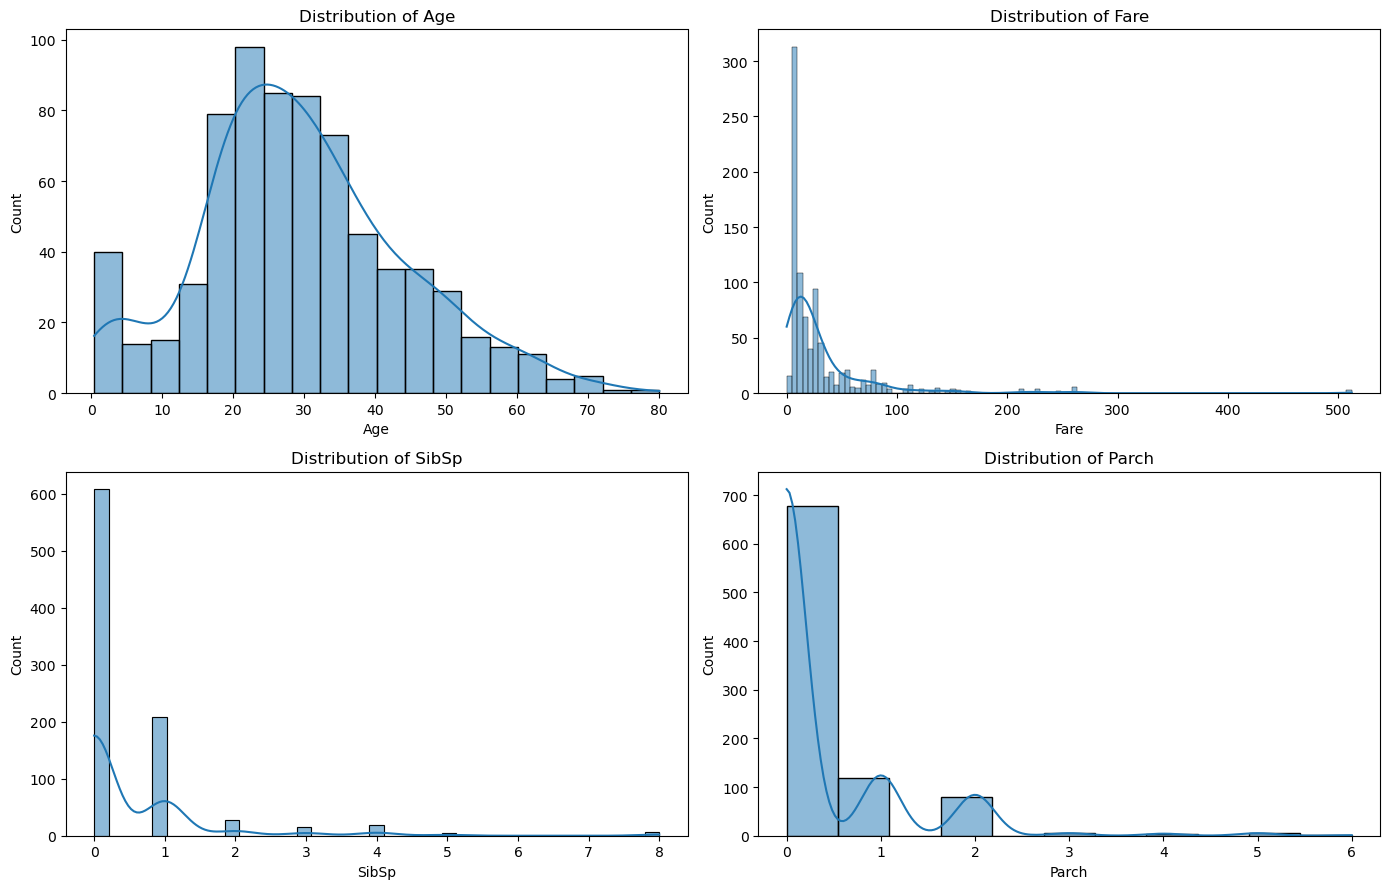

In [11]:
# NUMERICAL FEATURES — 

numerical_features = ["Age", "Fare", "SibSp", "Parch"]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, feature in zip(axes.flat, numerical_features):
    sns.histplot(
        data=train_df,
        x=feature,kde=True,ax=ax)
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

Insights

Age: Age is concentrated among young and middle-aged passengers, with some missing observations.

Fare: Fare is highly right-skewed, indicating that most passengers paid relatively low fares while a few paid very high fares.

SibSp: Most passengers travelled with zero or one sibling/spouse.

Parch: Most passengers travelled without parents or children, while larger family groups were less common.

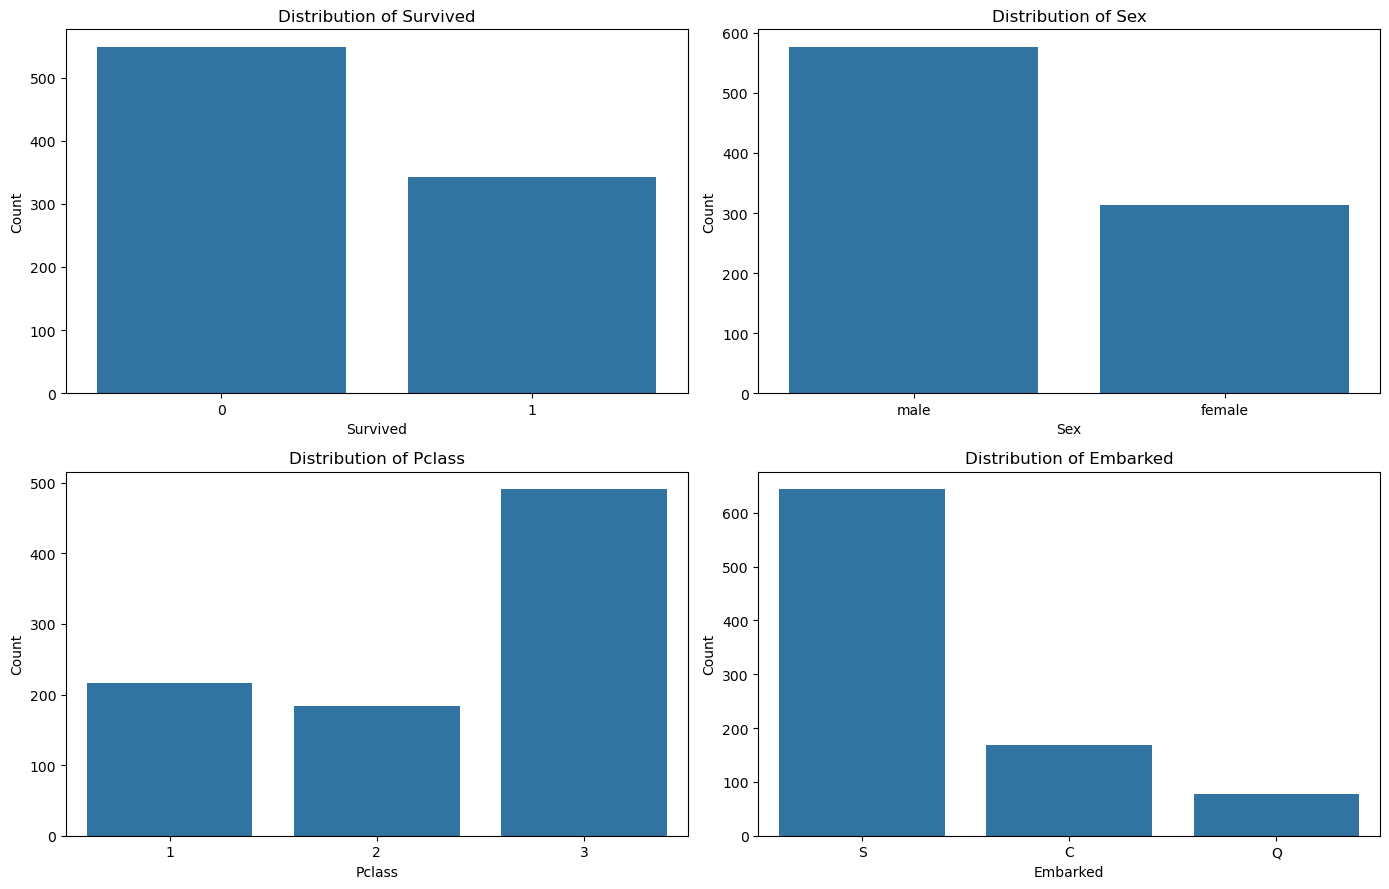

In [13]:
# CATEGORICAL FEATURES —

categorical_features = ["Survived", "Sex", "Pclass", "Embarked"]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, feature in zip(axes.flat, categorical_features):
    sns.countplot(
        data=train_df,
        x=feature,
        ax=ax)
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

Insights
1. Survived: The number of non-survivors is higher than survivors, showing that the target classes are somewhat imbalanced.
2. Sex: Male passengers considerably outnumber female passengers in the dataset.
3. Pclass: Third-class passengers form the largest passenger class, followed by first and second class.
4. Embarked: Most passengers embarked from Southampton (S), making it the dominant embarkation port.

## Bivariate Analysis

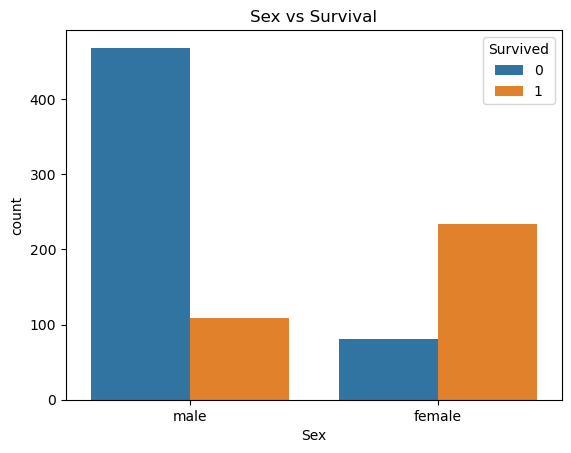

In [16]:
sns.countplot(x='Sex', hue='Survived', data=train_df)
plt.title('Sex vs Survival')
plt.show()

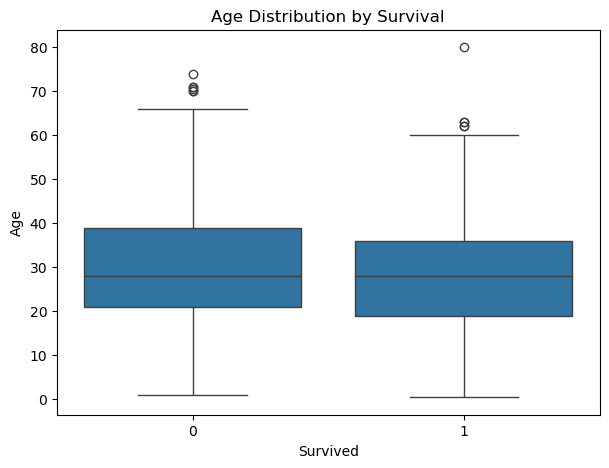

In [23]:
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=train_df,
    x="Survived",
    y="Age")
plt.title("Age Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Age")

plt.show()

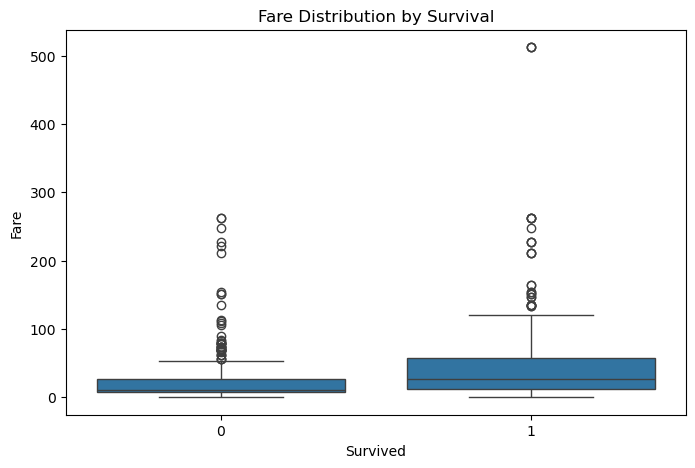

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=train_df,
    x="Survived",
    y="Fare")
plt.title("Fare Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.show()

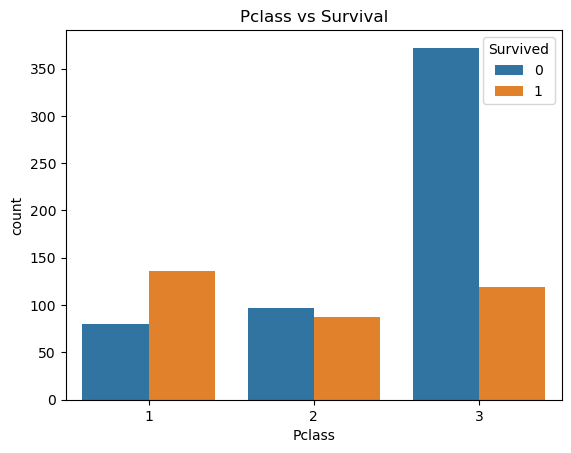

In [24]:
sns.countplot(x='Pclass', hue='Survived', data=train_df)
plt.title('Pclass vs Survival')
plt.show()

## Multivariate Analysis

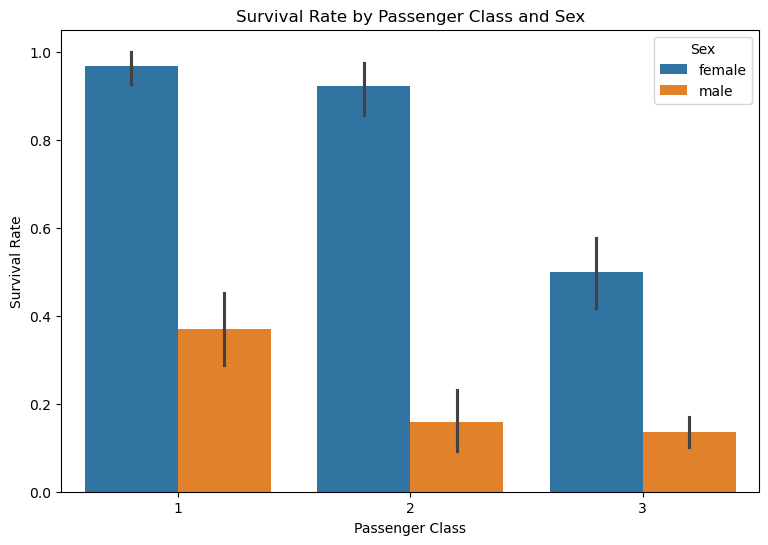

In [25]:
#Sex × Pclass × Survival
plt.figure(figsize=(9, 6))
sns.barplot(
    data=train_df,
    x="Pclass",
    y="Survived",
    hue="Sex")
plt.title("Survival Rate by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.legend(title="Sex")

plt.show()

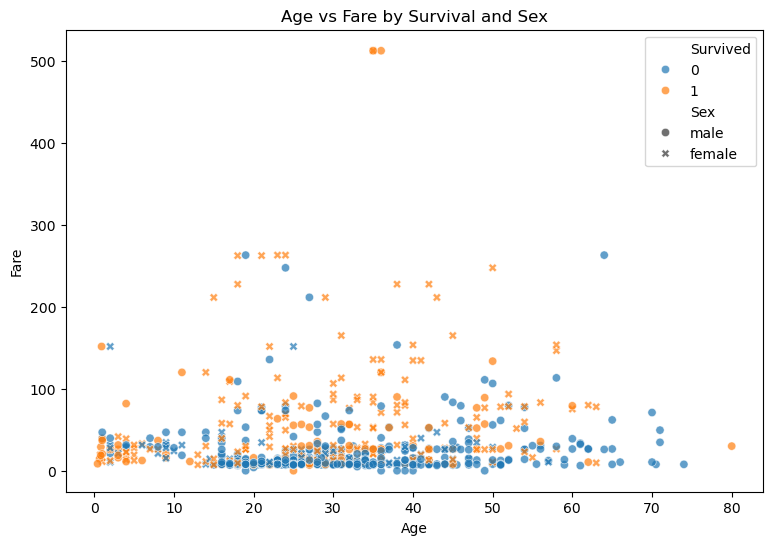

In [26]:
#Age × Sex × Survival
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=train_df,
    x="Age",
    y="Fare",
    hue="Survived",
    style="Sex",
    alpha=0.7)
plt.title("Age vs Fare by Survival and Sex")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

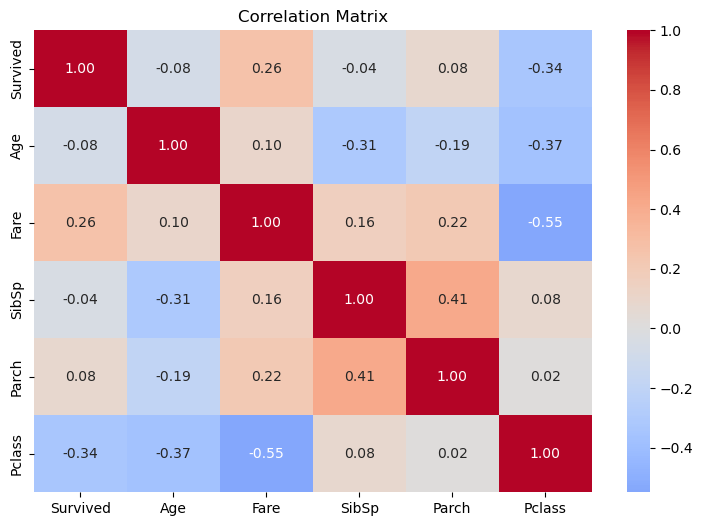

In [27]:
## COrrelation :
plt.figure(figsize=(9, 6))
correlation = train_df[
    ["Survived", "Age", "Fare", "SibSp", "Parch", "Pclass"]].corr()
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0)
plt.title("Correlation Matrix")
plt.show()

### Insights - 
1. Females had much higher survival rates
Female passengers survived significantly more than males.
Gender strongly influenced rescue priority.
    
2.  Children survived more than adults
Young passengers received rescue priority.
Survival decreased with increasing age.]

3.  High-fare passengers survived more
Expensive ticket holders had better survival chances.
Fare reflected economic and social status.

4. First-class passengers survived more
Passengers in 1st class had the highest survival probability.
Wealthier passengers received better access to safety.

5. Third-class passengers had the lowest survival
Most deaths occurred in 3rd class.
Lower economic class faced greater risk.

8. Small families survived better
Families with 2–4 members showed better survival.
Extremely large families struggled during evacuation.

9. Female passengers in all classes survived better
Gender effect remained strong across every class category.

10. Fare_Per_Person positively affected survival
Passengers spending more per person survived more often.
Wealth strongly influenced outcomes.
